# 🧬 PMOS Intelligence Platform
## Block 1 — Exploratory Data Analysis (EDA)
**Goal:** Understand the dataset deeply before touching any model.

We will cover:
- Loading and inspecting the data
- Missing value analysis
- Target variable distribution
- Hormone and metabolic feature distributions
- Correlation analysis
- Outlier detection

---
### Cell 1 — Import Libraries

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [2]:
import os

# Set working directory to notebook folder permanently
os.chdir('/Users/cirrus/Desktop/PMOS_PROJECT/notebook')

# Create all needed folders
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('../artifacts', exist_ok=True)

print('✅ Working directory:', os.getcwd())
print('✅ Folders created')

✅ Working directory: /Users/cirrus/Desktop/PMOS_PROJECT/notebook
✅ Folders created


---
### Cell 2 — Load Dataset

In [3]:
df = pd.read_excel('/Users/cirrus/Desktop/PMOS_PROJECT/notebook/data/PCOS_data_without_infertility.xlsx', sheet_name='Full_new')

print(f'✅ Dataset loaded successfully')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Dataset loaded successfully
   Shape: 541 rows × 45 columns


---
### Cell 3 — First Look at the Data

In [4]:
# First 5 rows
print('=== FIRST 5 ROWS ===')
df.head()

=== FIRST 5 ROWS ===


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.600,152.000,19.300,15,78,22,10.480,2,5,7.000,0,0,1.990,1.990,7.950,3.680,2.160,36,30,0.833,0.680,2.070,45.160,17.100,0.570,92.000,0,0,0,0,0,1.000,0,110,80,3,3,18.000,18.000,8.500,NaN
1,2,2,0,36,65.000,161.500,24.921,15,74,20,11.700,2,5,11.000,1,0,60.800,1.990,6.730,1.090,6.174,38,32,0.842,3.160,1.530,20.090,61.300,0.970,92.000,0,0,0,0,0,0.000,0,120,70,3,5,15.000,14.000,3.700,NaN
2,3,3,1,33,68.800,165.000,25.271,11,72,18,11.800,2,5,10.000,1,0,494.080,494.080,5.540,0.880,6.295,40,36,0.900,2.540,6.630,10.520,49.700,0.360,84.000,0,0,0,1,1,1.000,0,120,80,13,15,18.000,20.000,10.000,NaN
3,4,4,0,37,65.000,148.000,29.675,13,72,20,12.000,2,5,4.000,0,0,1.990,1.990,8.060,2.360,3.415,42,36,0.857,16.410,1.220,36.900,33.400,0.360,76.000,0,0,0,0,0,0.000,0,120,70,2,2,15.000,14.000,7.500,NaN
4,5,5,0,25,52.000,161.000,20.061,11,72,18,10.000,2,5,1.000,1,0,801.450,801.450,3.980,0.900,4.422,37,30,0.811,3.570,2.260,30.090,43.800,0.380,84.000,0,0,0,1,0,0.000,0,120,80,3,4,16.000,14.000,7.000,NaN


In [5]:
# Last 5 rows
print('=== LAST 5 ROWS ===')
df.tail()

=== LAST 5 ROWS ===


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
536,537,537,0,35,50.000,164.592,18.500,17,72,16,11.000,2,5,8.000,0,1,1.990,1.990,10.060,1.810,5.558,28,26,0.929,1.110,1.700,5.300,36.600,0.250,92.000,0,0,0,0,0,0.000,0,110,70,1,0,17.500,10.000,6.700,NaN
537,538,538,0,30,63.200,158.000,25.300,15,72,18,10.800,2,5,4.000,1,1,80.130,1.990,5.070,2.840,1.785,34,32,0.941,2.050,5.600,21.090,23.000,0.250,108.000,1,0,0,0,0,0.000,0,110,70,9,7,19.000,18.000,8.200,NaN
538,539,539,0,36,54.000,152.000,23.400,13,74,20,10.800,2,6,8.000,0,0,1.990,1.990,11.960,2.780,4.302,30,28,0.933,2.870,3.700,96.410,22.500,0.250,92.000,0,0,0,0,0,0.000,0,110,80,1,0,18.000,9.000,7.300,NaN
539,540,540,0,27,50.000,150.000,22.200,15,74,20,12.000,4,2,2.000,0,0,292.920,1.990,4.400,4.330,1.016,28,26,0.929,2.500,5.200,38.890,22.400,0.250,115.000,0,0,0,0,1,0.000,0,110,70,7,6,18.000,16.000,11.500,NaN
540,541,541,1,23,82.000,165.000,30.100,13,80,20,10.200,4,7,2.000,0,0,1.990,1.990,3.990,4.300,0.928,48,46,0.958,1.660,20,20.740,17.400,0.370,108.000,1,1,1,1,1,1.000,0,120,70,9,10,19.000,18.000,6.900,NaN


In [6]:
# Column names — see all features
print('=== ALL COLUMN NAMES ===')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

=== ALL COLUMN NAMES ===
   1. Sl. No
   2. Patient File No.
   3. PCOS (Y/N)
   4.  Age (yrs)
   5. Weight (Kg)
   6. Height(Cm) 
   7. BMI
   8. Blood Group
   9. Pulse rate(bpm) 
  10. RR (breaths/min)
  11. Hb(g/dl)
  12. Cycle(R/I)
  13. Cycle length(days)
  14. Marraige Status (Yrs)
  15. Pregnant(Y/N)
  16. No. of aborptions
  17.   I   beta-HCG(mIU/mL)
  18. II    beta-HCG(mIU/mL)
  19. FSH(mIU/mL)
  20. LH(mIU/mL)
  21. FSH/LH
  22. Hip(inch)
  23. Waist(inch)
  24. Waist:Hip Ratio
  25. TSH (mIU/L)
  26. AMH(ng/mL)
  27. PRL(ng/mL)
  28. Vit D3 (ng/mL)
  29. PRG(ng/mL)
  30. RBS(mg/dl)
  31. Weight gain(Y/N)
  32. hair growth(Y/N)
  33. Skin darkening (Y/N)
  34. Hair loss(Y/N)
  35. Pimples(Y/N)
  36. Fast food (Y/N)
  37. Reg.Exercise(Y/N)
  38. BP _Systolic (mmHg)
  39. BP _Diastolic (mmHg)
  40. Follicle No. (L)
  41. Follicle No. (R)
  42. Avg. F size (L) (mm)
  43. Avg. F size (R) (mm)
  44. Endometrium (mm)
  45. Unnamed: 44


---
### Cell 4 — Data Types and Basic Info

In [7]:
print('=== DATA TYPES ===')
print(df.dtypes)
print(f'\nNumerical columns : {df.select_dtypes(include=np.number).shape[1]}')
print(f'Categorical columns: {df.select_dtypes(include="object").shape[1]}')

=== DATA TYPES ===
Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int64
 Age (yrs)                  int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of aborptions           int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)     object
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                 object
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                flo

In [8]:
print('=== DATASET INFO ===')
df.info()

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-

---
### Cell 5 — Duplicate Check

In [9]:
duplicates = df.duplicated().sum()
print(f'=== DUPLICATE ROWS ===')
print(f'  Total duplicates: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'  ✅ Duplicates removed. New shape: {df.shape}')
else:
    print(f'  ✅ No duplicates found')

=== DUPLICATE ROWS ===
  Total duplicates: 0
  ✅ No duplicates found


---
### Cell 6 — Target Variable Analysis
**Target:** `PCOS (Y/N)` — this is what we are predicting

=== TARGET VARIABLE DISTRIBUTION ===
  PMOS Negative (0): 364 patients (67.3%)
  PMOS Positive (1): 177 patients (32.7%)
  Imbalance ratio  : 2.06:1


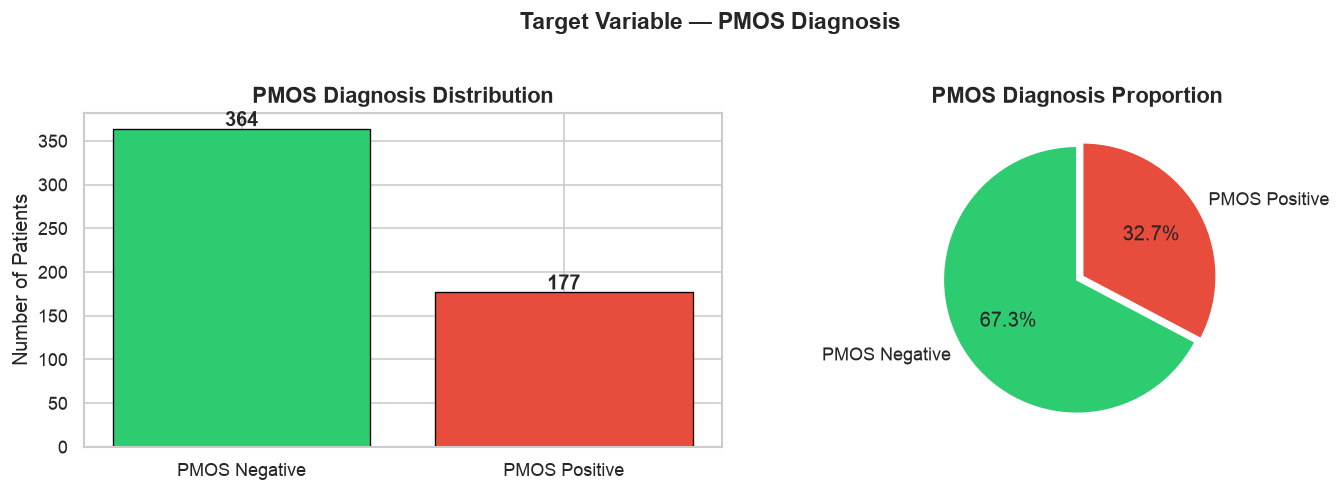


⚠️  Class imbalance noted — will handle in Block 2 with SMOTE+ADASYN


In [10]:
# Identify target column
# The target column may be named differently — check and update if needed
target_col = 'PCOS (Y/N)'

print('=== TARGET VARIABLE DISTRIBUTION ===')
counts = df[target_col].value_counts()
percentages = df[target_col].value_counts(normalize=True) * 100

print(f'  PMOS Negative (0): {counts[0]} patients ({percentages[0]:.1f}%)')
print(f'  PMOS Positive (1): {counts[1]} patients ({percentages[1]:.1f}%)')
print(f'  Imbalance ratio  : {counts[0]/counts[1]:.2f}:1')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['PMOS Negative', 'PMOS Positive'], counts,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
axes[0].set_title('PMOS Diagnosis Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=['PMOS Negative', 'PMOS Positive'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('PMOS Diagnosis Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — PMOS Diagnosis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/01_target_distribution.png', bbox_inches='tight')
plt.show()
print('\n⚠️  Class imbalance noted — will handle in Block 2 with SMOTE+ADASYN')

---
### Cell 7 — Missing Value Analysis

In [11]:
print('=== MISSING VALUE ANALYSIS ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
missing_df_filtered = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df_filtered) == 0:
    print('  ✅ No missing values found in dataset')
else:
    print(f'  ⚠️  {len(missing_df_filtered)} columns have missing values:\n')
    print(missing_df_filtered.to_string())

=== MISSING VALUE ANALYSIS ===
  ⚠️  3 columns have missing values:

                       Missing Count  Missing %
Unnamed: 44                      539     99.630
Fast food (Y/N)                    1      0.185
Marraige Status (Yrs)              1      0.185


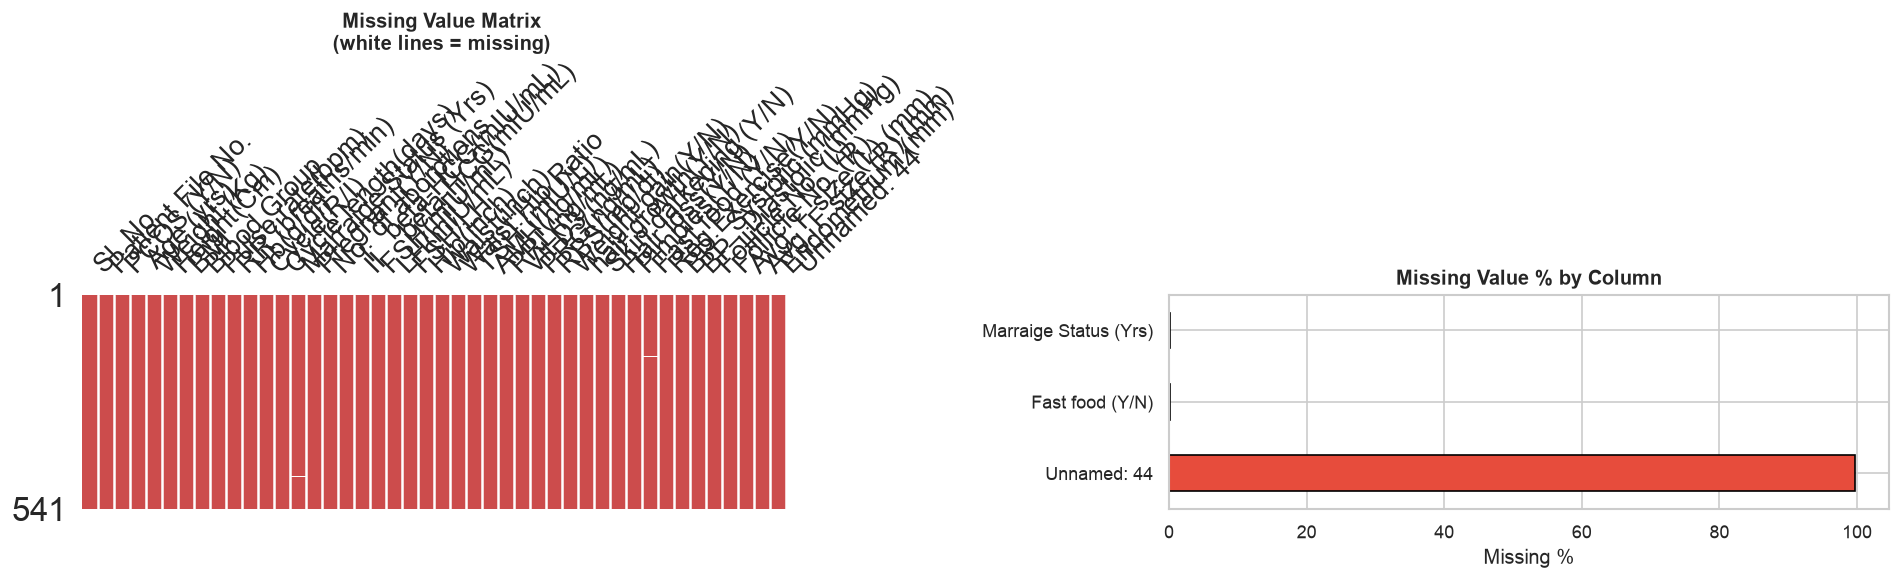

In [12]:
# Missing value heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Missingno matrix
msno.matrix(df, ax=axes[0], sparkline=False, color=(0.8, 0.3, 0.3))
axes[0].set_title('Missing Value Matrix\n(white lines = missing)', 
                   fontsize=12, fontweight='bold')

# Missing % bar chart
if len(missing_df_filtered) > 0:
    missing_df_filtered['Missing %'].plot(kind='barh', ax=axes[1], 
                                           color='#e74c3c', edgecolor='black')
    axes[1].set_title('Missing Value % by Column', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Missing %')
else:
    axes[1].text(0.5, 0.5, '✅ No Missing Values!',
                 ha='center', va='center', fontsize=14,
                 color='green', fontweight='bold',
                 transform=axes[1].transAxes)
    axes[1].set_title('Missing Value % by Column', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/02_missing_values.png', bbox_inches='tight')
plt.show()

---
### Cell 8 — Statistical Summary

In [13]:
print('=== STATISTICAL SUMMARY (Numerical Features) ===')
df.describe().T

=== STATISTICAL SUMMARY (Numerical Features) ===


,count,mean,std,min,25%,50%,75%,max
Sl. No,541.000,271.000,156.318,1.000,136.000,271.000,406.000,541.000
Patient File No.,541.000,271.000,156.318,1.000,136.000,271.000,406.000,541.000
PCOS (Y/N),541.000,0.327,0.470,0.000,0.000,0.000,1.000,1.000
Age (yrs),541.000,31.431,5.411,20.000,28.000,31.000,35.000,48.000
Weight (Kg),541.000,59.637,11.028,31.000,52.000,59.000,65.000,108.000
Height(Cm),541.000,156.485,6.034,137.000,152.000,156.000,160.000,180.000
BMI,541.000,24.311,4.056,12.418,21.641,24.238,26.635,38.900
Blood Group,541.000,13.802,1.841,11.000,13.000,14.000,15.000,18.000
Pulse rate(bpm),541.000,73.248,4.430,13.000,72.000,72.000,74.000,82.000
RR (breaths/min),541.000,19.244,1.689,16.000,18.000,18.000,20.000,28.000


---
### Cell 9 — Hormone Feature Analysis
Key hormones in PMOS: LH, FSH, AMH, Testosterone, TSH, Prolactin

In [14]:
# Define hormone columns — update names if different in your dataset
hormone_cols = [
    col for col in df.columns 
    if any(h in col.upper() for h in ['LH', 'FSH', 'AMH', 'TSH', 'PRL', 'TESTOSTERONE', 'PROLACTIN'])
]

print('=== HORMONE COLUMNS IDENTIFIED ===')
for col in hormone_cols:
    print(f'  → {col}')

if len(hormone_cols) == 0:
    print('  ⚠️  No hormone columns auto-detected.')
    print('  Please check column names above and update hormone_cols manually.')

=== HORMONE COLUMNS IDENTIFIED ===
  → FSH(mIU/mL)
  → LH(mIU/mL)
  → FSH/LH
  → TSH (mIU/L)
  → AMH(ng/mL)
  → PRL(ng/mL)


In [15]:
# Convert AMH to numeric — it has string values mixed in
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'], errors='coerce')

print('✅ AMH converted to float')
print(f'   dtype: {df["AMH(ng/mL)"].dtype}')
print(f'   Missing values created: {df["AMH(ng/mL)"].isnull().sum()}')

✅ AMH converted to float
   dtype: float64
   Missing values created: 1


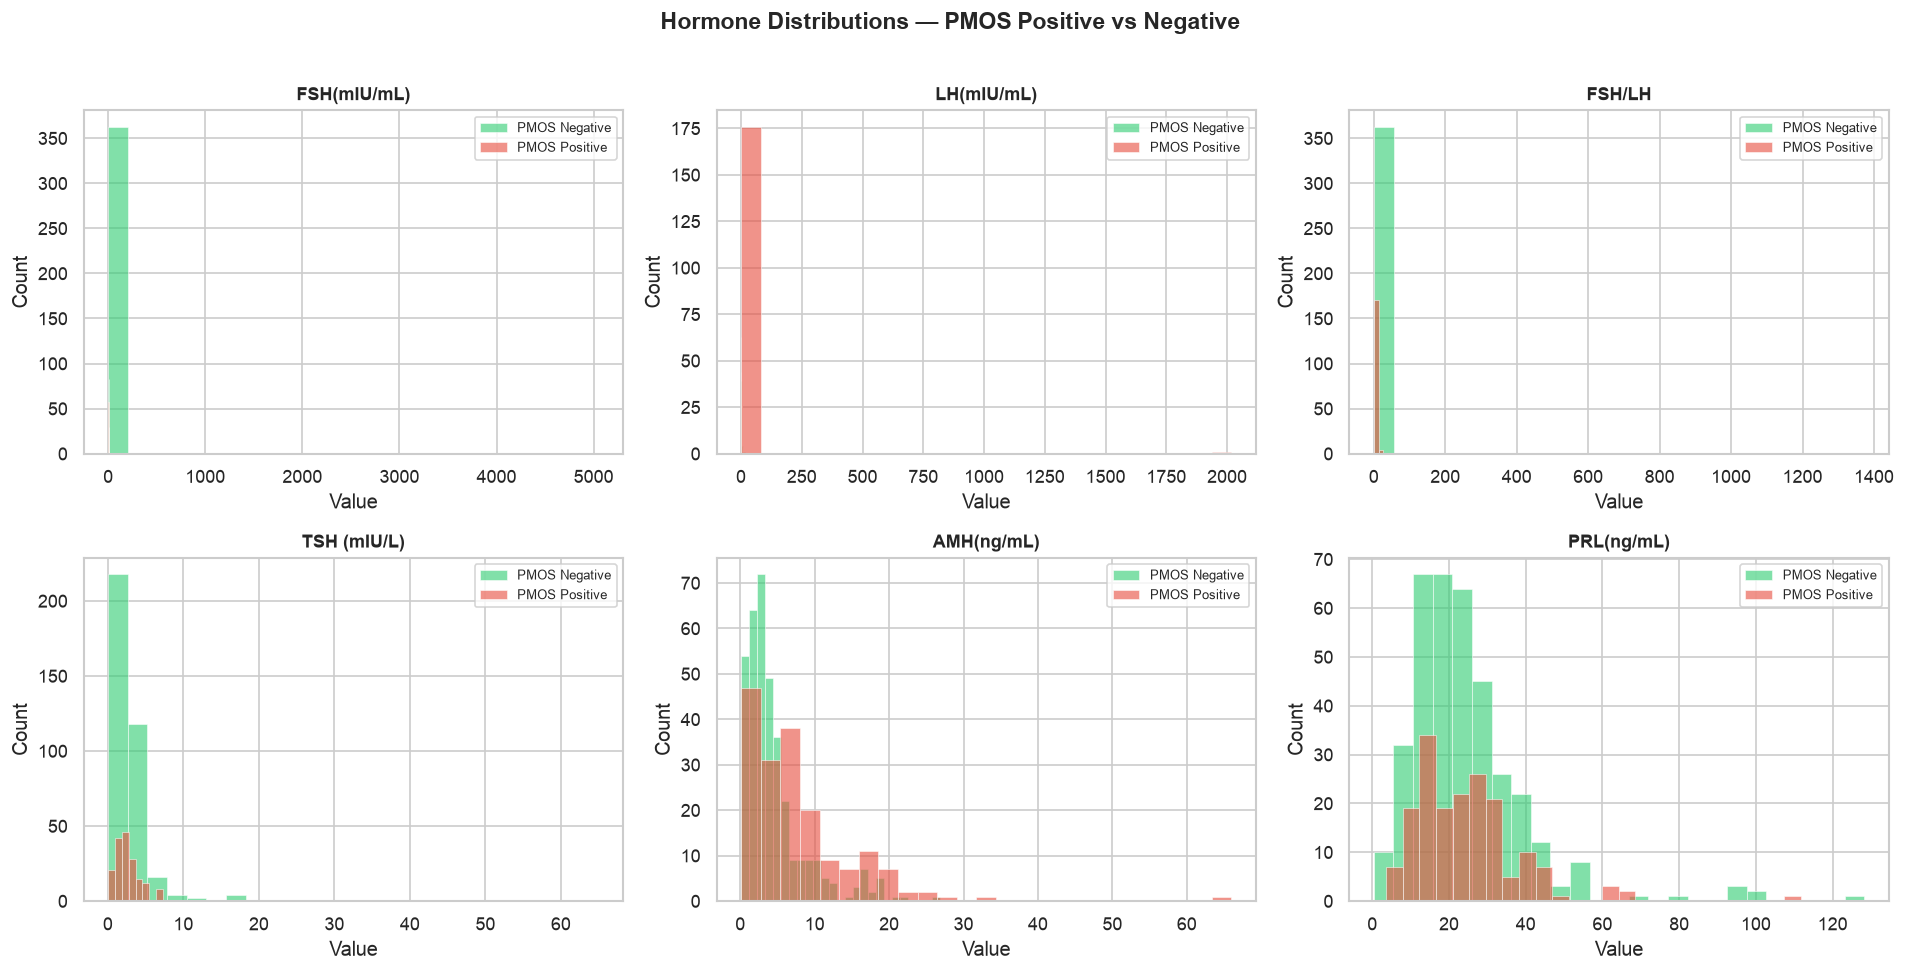

In [16]:
if len(hormone_cols) > 0:
    n_cols = 3
    n_rows = (len(hormone_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = np.array(axes).flatten()  # ← this fixes the issue
    
    for i, col in enumerate(hormone_cols):
        for label, color, name in zip([0, 1], 
                                       ['#2ecc71', '#e74c3c'], 
                                       ['PMOS Negative', 'PMOS Positive']):
            subset = df[df[target_col] == label][col].dropna()
            axes[i].hist(subset, bins=25, alpha=0.6, color=color, 
                        label=name, edgecolor='white', linewidth=0.5)
        
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')
        axes[i].legend(fontsize=8)
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Hormone Distributions — PMOS Positive vs Negative', 
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('outputs/plots/03_hormone_distributions.png', bbox_inches='tight')
    plt.show()

---
### Cell 10 — LH/FSH Ratio Analysis
The LH/FSH ratio is one of the most important PMOS diagnostic markers.
A ratio > 2 strongly suggests PMOS.

LH column  : ['LH(mIU/mL)']
FSH column : ['FSH(mIU/mL)']

=== LH/FSH RATIO STATISTICS BY GROUP ===
             count  mean    std   min   25%   50%   75%     max
PCOS (Y/N)                                                     
0          364.000 0.510  0.425 0.001 0.242 0.423 0.642   4.381
1          177.000 3.271 34.986 0.003 0.300 0.491 0.928 466.051


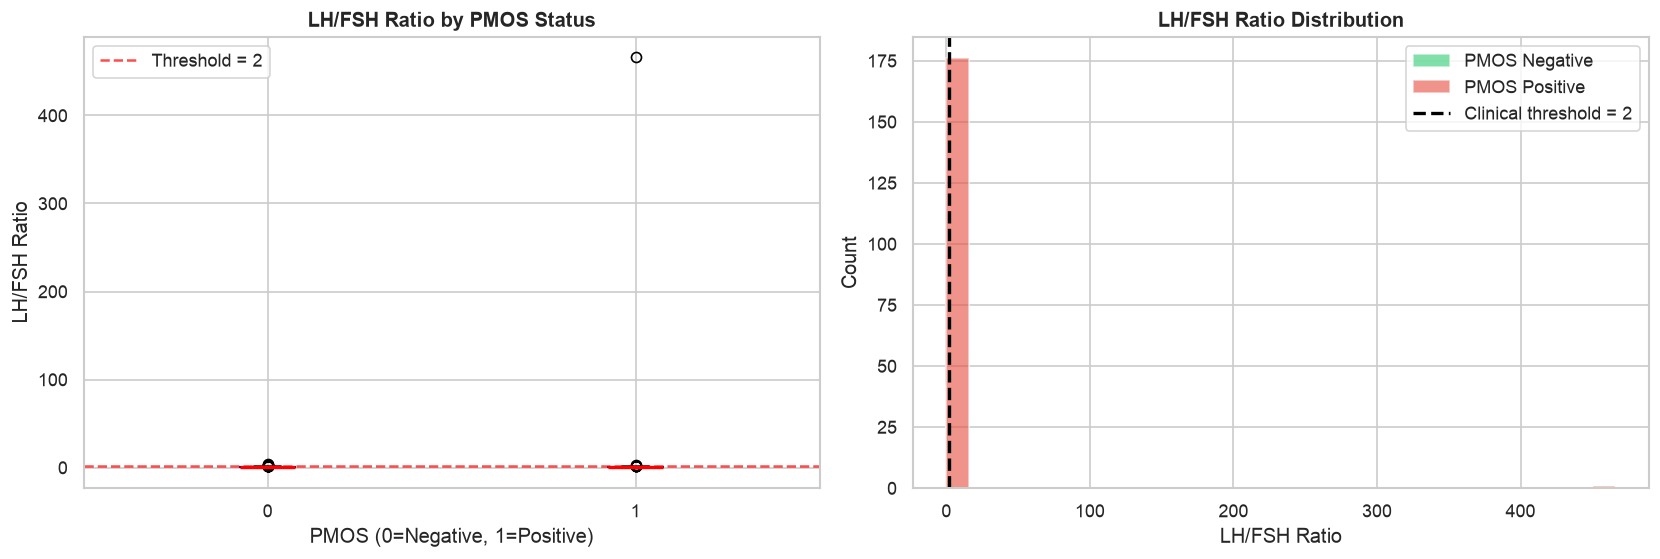

In [17]:
# LH/FSH ratio — update column names if needed
lh_col  = [col for col in df.columns if 'LH' in col.upper() and 'FSH' not in col.upper()]
fsh_col = [col for col in df.columns if 'FSH' in col.upper() and 'LH'  not in col.upper()]

print(f'LH column  : {lh_col}')
print(f'FSH column : {fsh_col}')

if lh_col and fsh_col:
    lh_col  = lh_col[0]
    fsh_col = fsh_col[0]
    
    # Calculate ratio
    df['LH_FSH_Ratio'] = df[lh_col] / df[fsh_col]
    
    print(f'\n=== LH/FSH RATIO STATISTICS BY GROUP ===')
    print(df.groupby(target_col)['LH_FSH_Ratio'].describe().round(3))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot
    df.boxplot(column='LH_FSH_Ratio', by=target_col, ax=axes[0],
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2))
    axes[0].set_title('LH/FSH Ratio by PMOS Status', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('PMOS (0=Negative, 1=Positive)')
    axes[0].set_ylabel('LH/FSH Ratio')
    axes[0].axhline(y=2, color='red', linestyle='--', alpha=0.7, label='Threshold = 2')
    axes[0].legend()
    plt.suptitle('')  # Remove auto title
    
    # Distribution
    for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], 
                                   ['PMOS Negative', 'PMOS Positive']):
        subset = df[df[target_col] == label]['LH_FSH_Ratio'].dropna()
        axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=name)
    axes[1].axvline(x=2, color='black', linestyle='--', linewidth=2, label='Clinical threshold = 2')
    axes[1].set_title('LH/FSH Ratio Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('LH/FSH Ratio')
    axes[1].set_ylabel('Count')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('outputs/plots/04_LH_FSH_ratio.png', bbox_inches='tight')
    plt.show()
else:
    print('\n⚠️  LH or FSH column not found. Check column names and update manually.')

---
### Cell 11 — Metabolic Feature Analysis
BMI, Blood Pressure, Glucose, Insulin

=== METABOLIC COLUMNS IDENTIFIED ===
  → Weight (Kg)
  → BMI
  → Blood Group
  → Pulse rate(bpm) 
  → Hip(inch)
  → Waist(inch)
  → Waist:Hip Ratio
  → Weight gain(Y/N)
  → BP _Systolic (mmHg)
  → BP _Diastolic (mmHg)


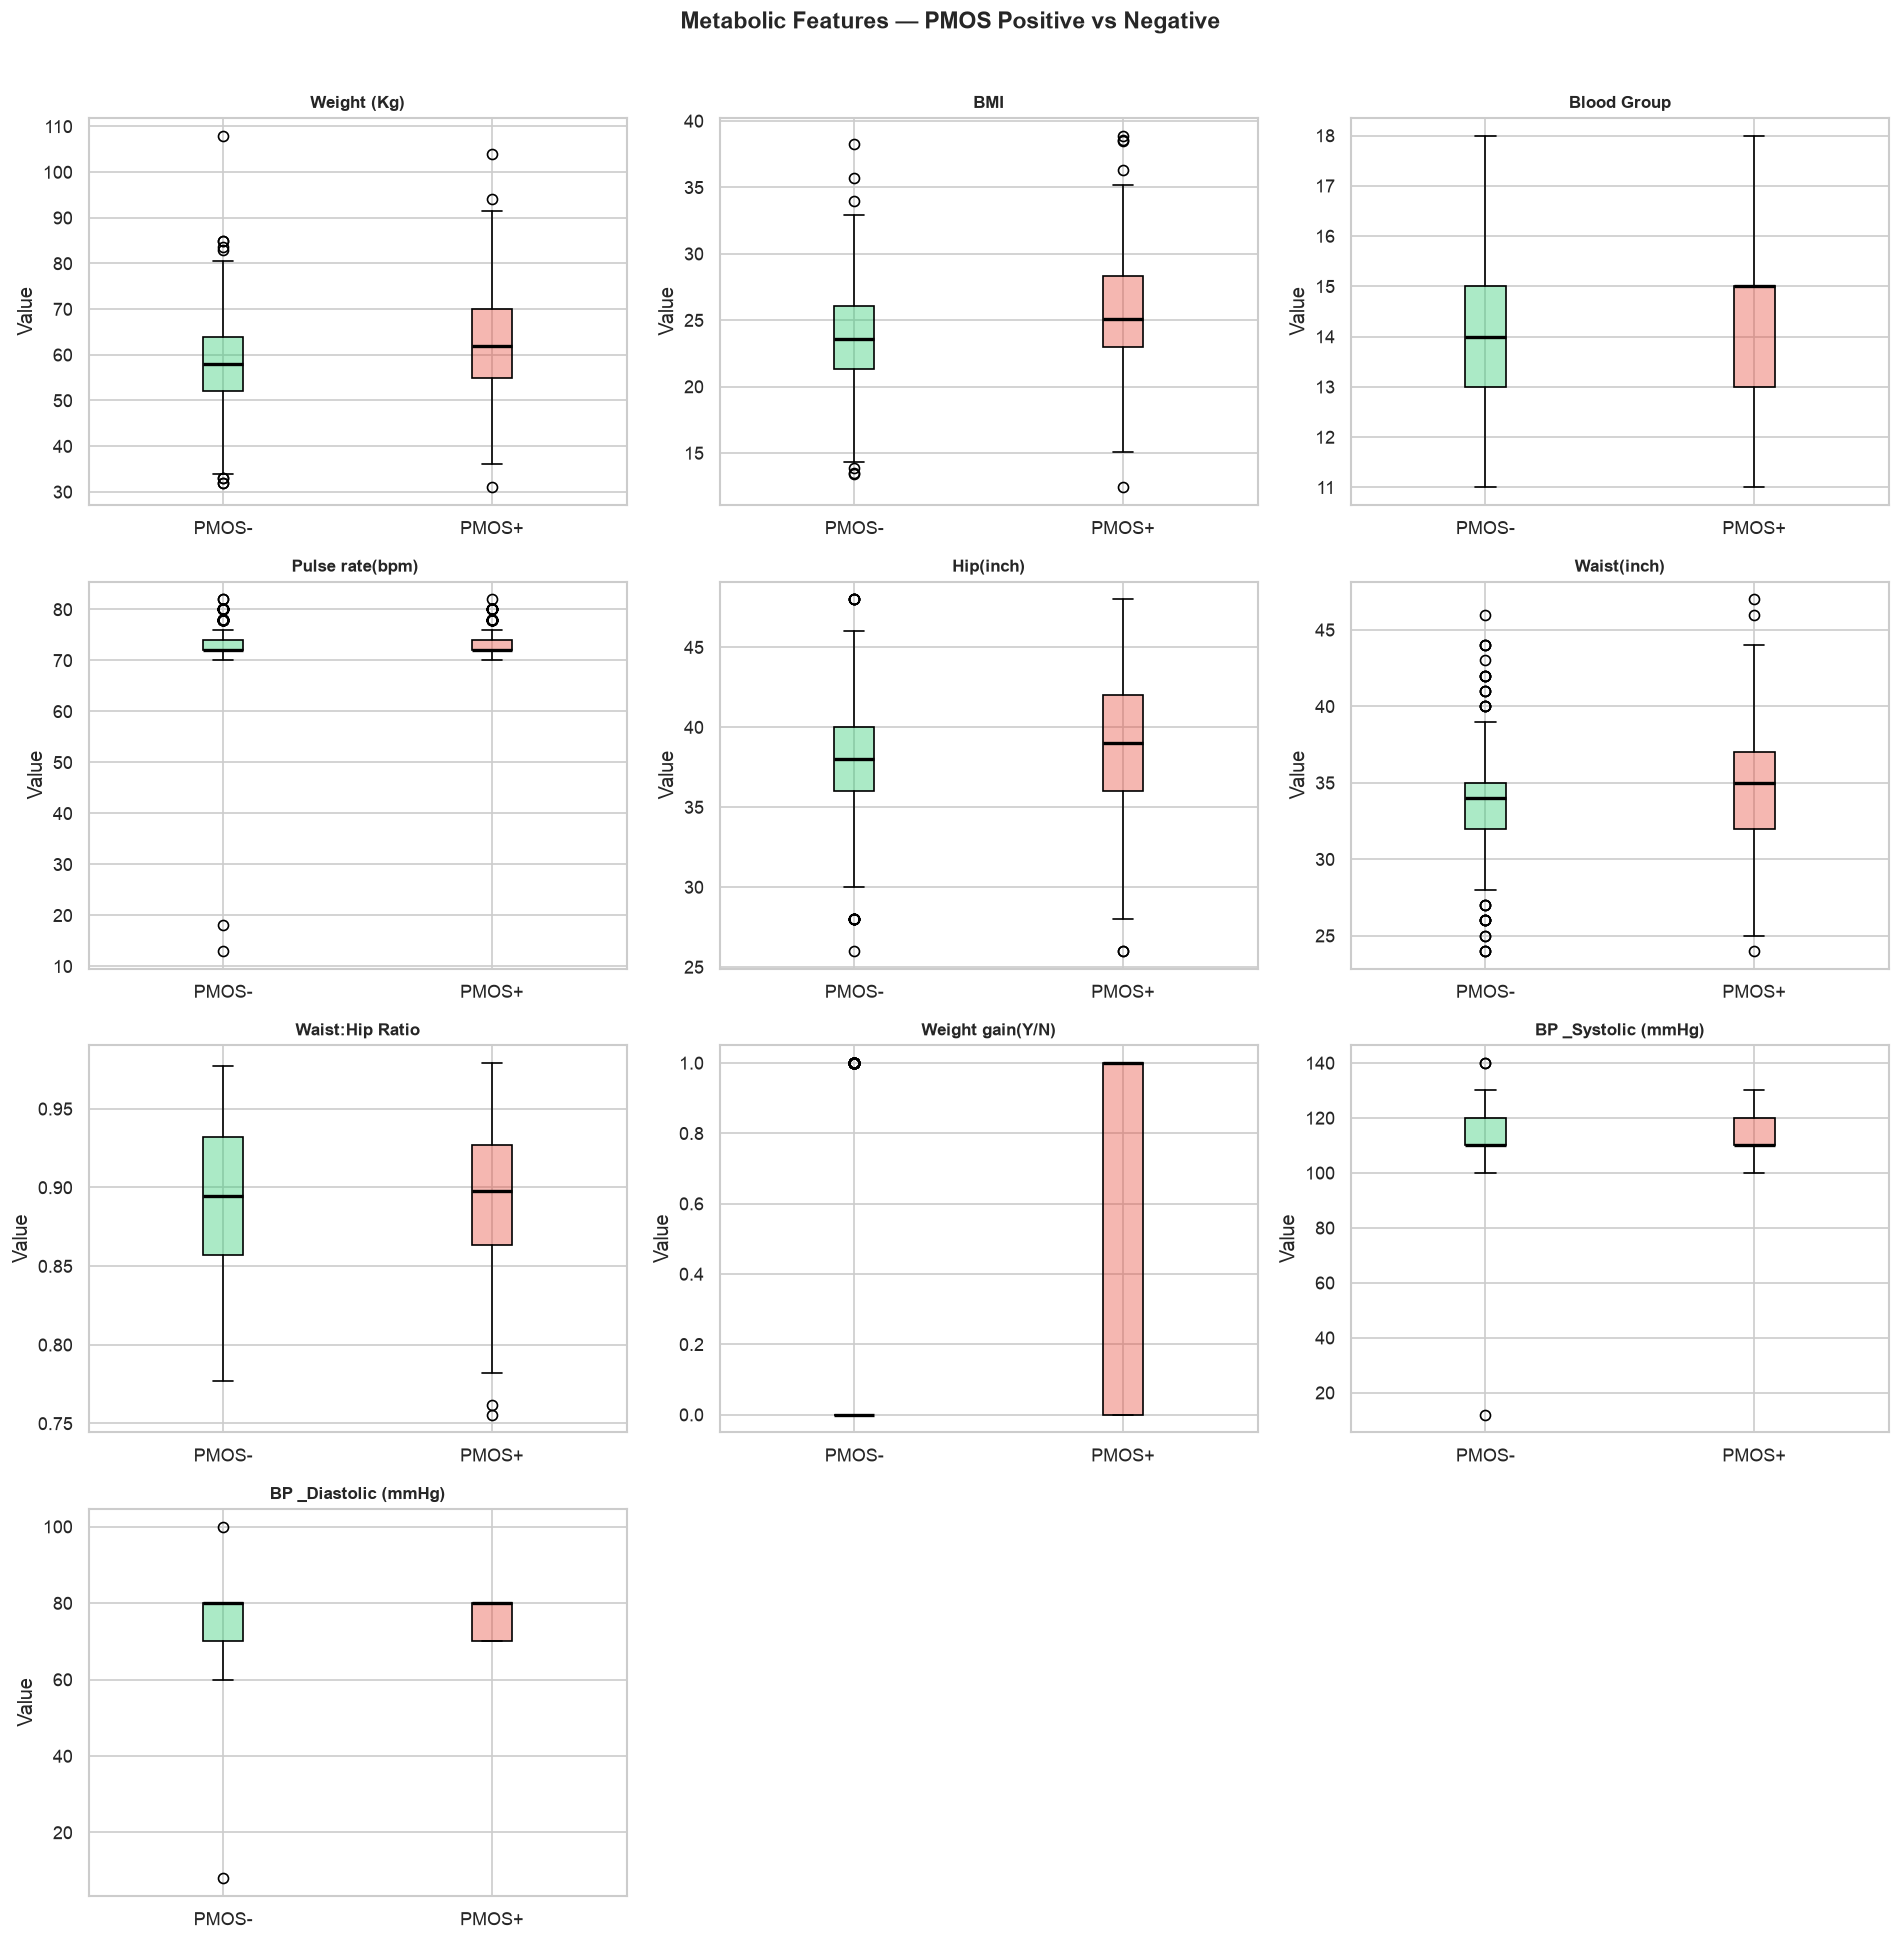

In [18]:
# Identify metabolic columns
metabolic_keywords = ['BMI', 'BP', 'BLOOD', 'GLUCOSE', 'INSULIN', 
                       'WEIGHT', 'WAIST', 'HIP', 'PULSE']
metabolic_cols = [
    col for col in df.columns 
    if any(k in col.upper() for k in metabolic_keywords)
]

print('=== METABOLIC COLUMNS IDENTIFIED ===')
for col in metabolic_cols:
    print(f'  → {col}')

# Boxplots — metabolic features by PMOS status
if len(metabolic_cols) > 0:
    n_cols = 3
    n_rows = (len(metabolic_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(metabolic_cols):
        data_groups = [df[df[target_col] == 0][col].dropna(),
                       df[df[target_col] == 1][col].dropna()]
        bp = axes[i].boxplot(data_groups, tick_labels=['PMOS-', 'PMOS+'],
                      patch_artist=True)
        bp['boxes'][0].set_facecolor('#2ecc7166')
        bp['boxes'][1].set_facecolor('#e74c3c66')
        for median in bp['medians']:
            median.set_color('black')
            median.set_linewidth(2)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Value')
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Metabolic Features — PMOS Positive vs Negative',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('outputs/plots/05_metabolic_features.png', bbox_inches='tight')
    plt.show()

---
### Cell 12 — Correlation Heatmap

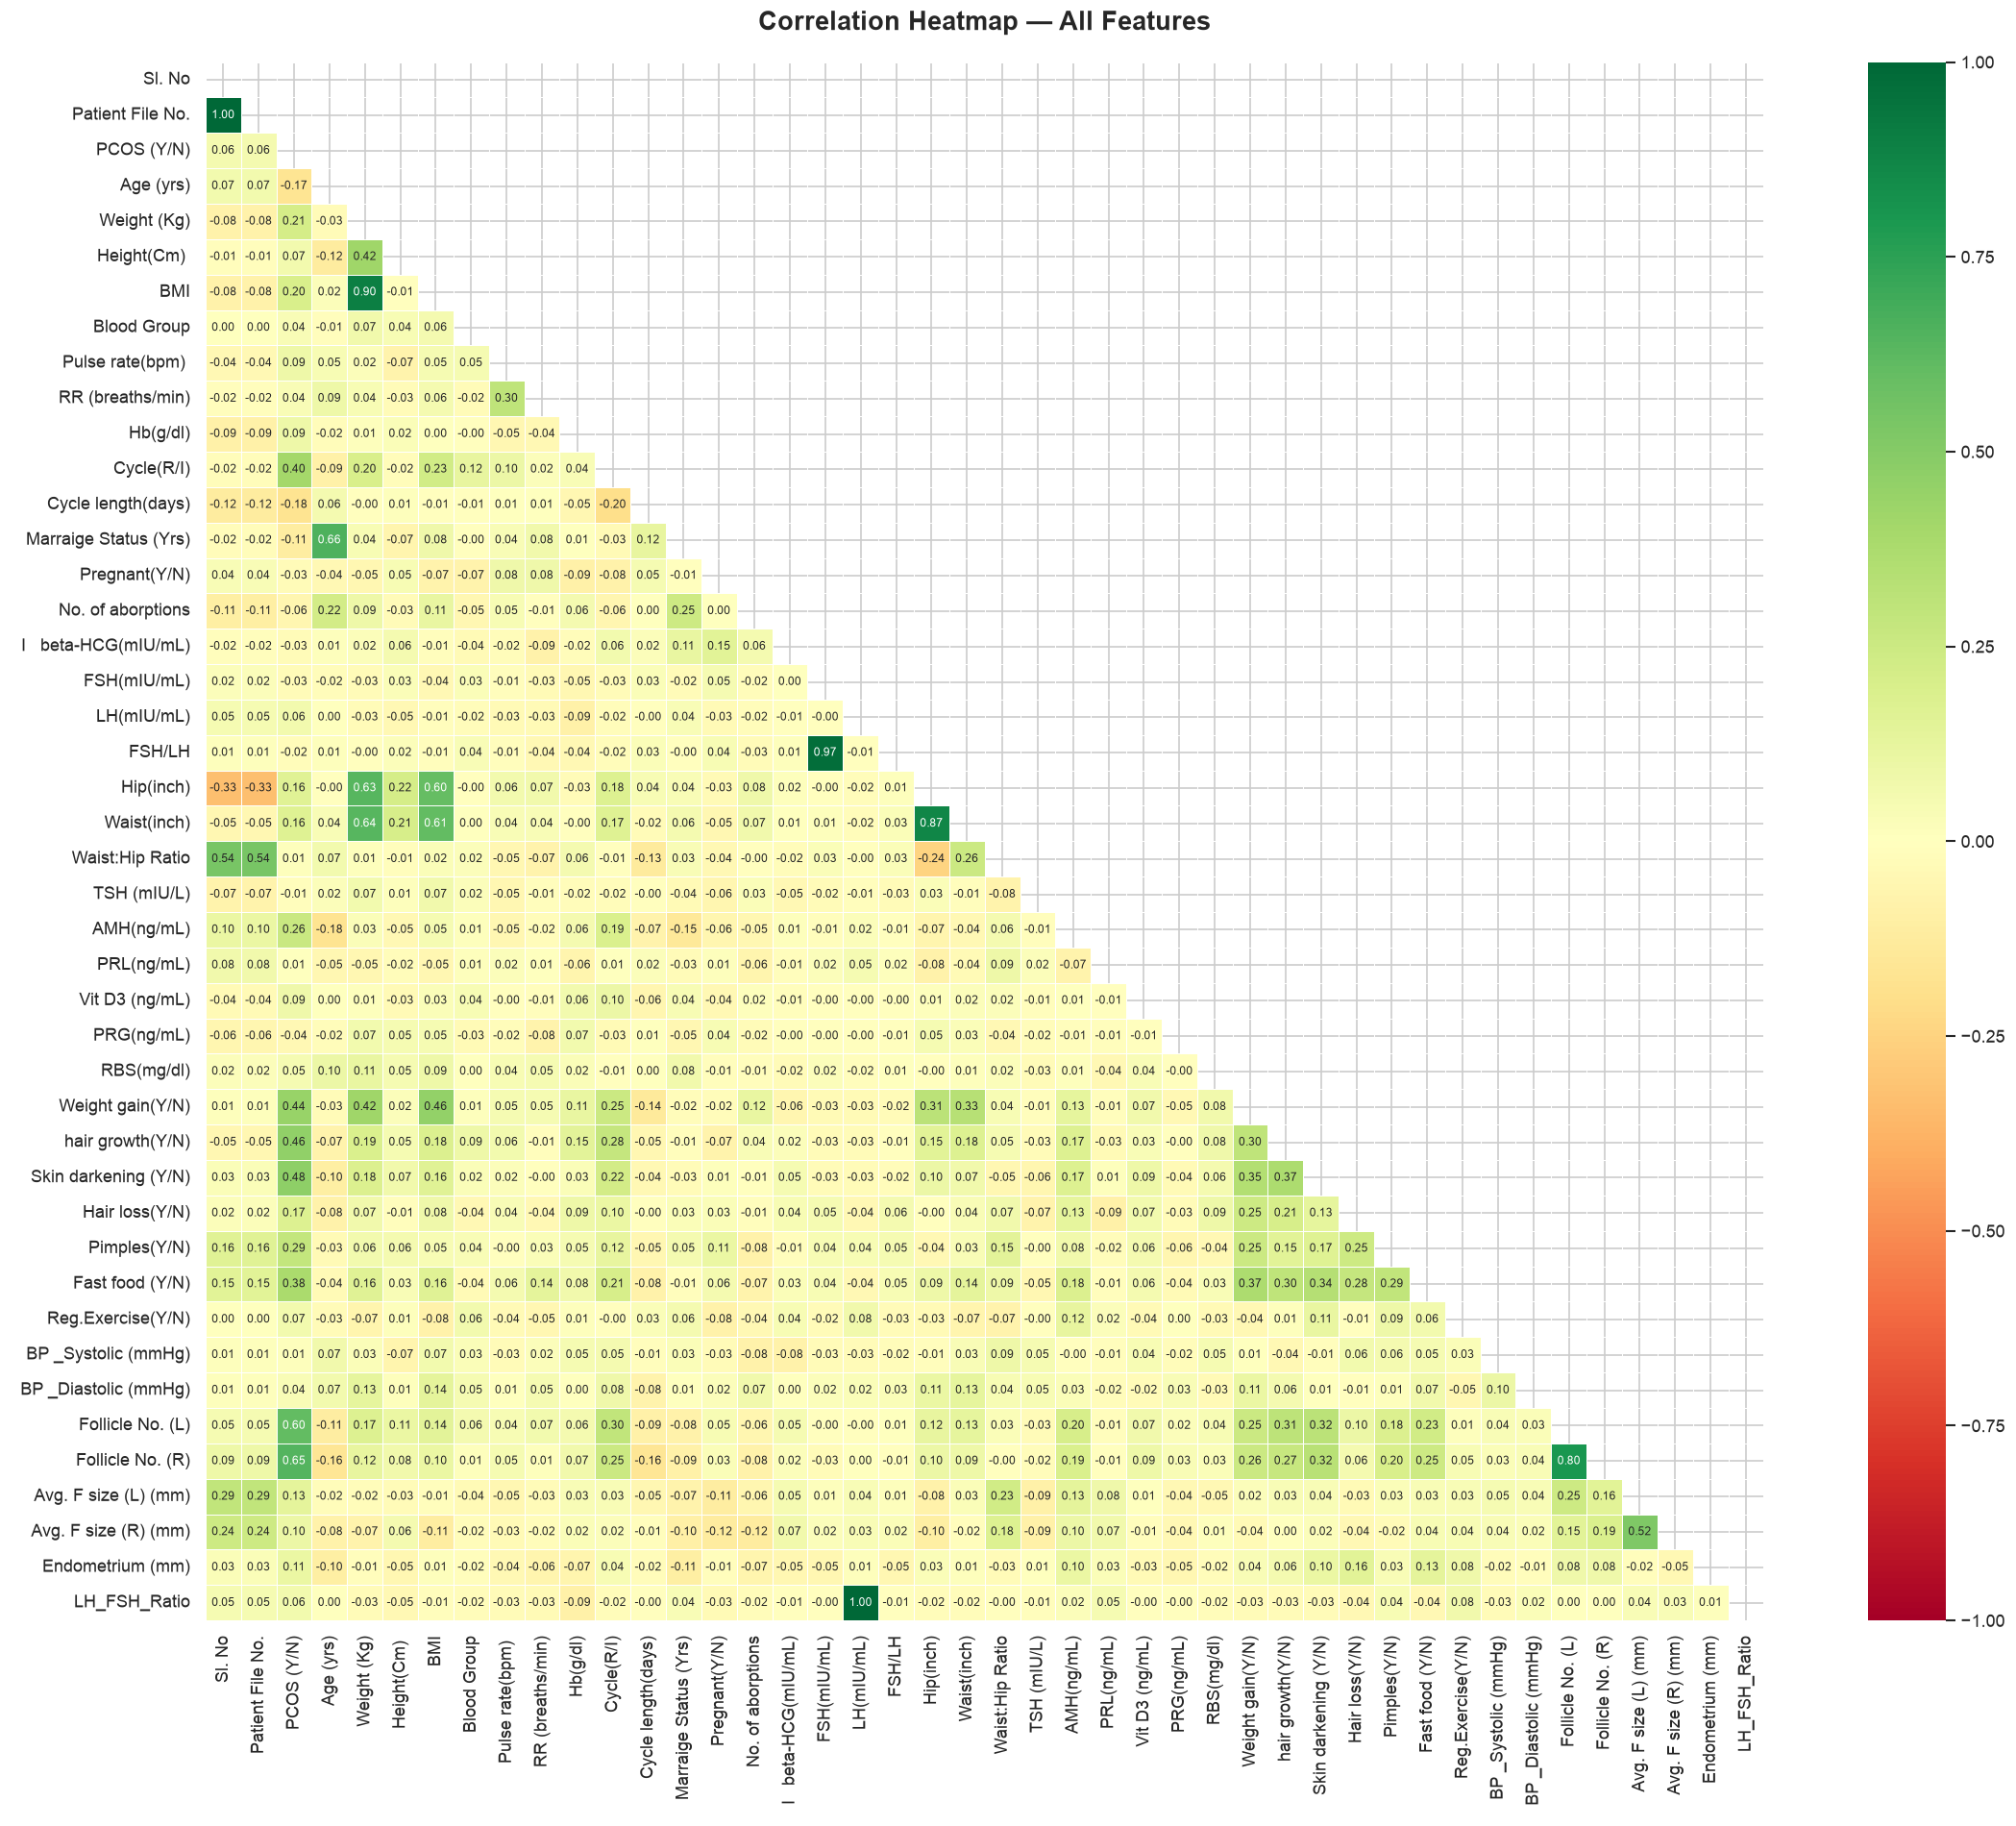

In [19]:
# Select numerical columns only
numerical_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    vmin=-1, vmax=1
)
plt.title('Correlation Heatmap — All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/plots/06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

=== TOP FEATURES CORRELATED WITH PMOS ===

Top 15 most correlated features:
Follicle No. (R)        0.648
Follicle No. (L)        0.603
Skin darkening (Y/N)    0.476
hair growth(Y/N)        0.465
Weight gain(Y/N)        0.441
Cycle(R/I)              0.402
Fast food (Y/N)         0.378
Pimples(Y/N)            0.286
AMH(ng/mL)              0.264
Weight (Kg)             0.212
BMI                     0.200
Cycle length(days)     -0.178
Hair loss(Y/N)          0.173
 Age (yrs)             -0.169
Waist(inch)             0.165


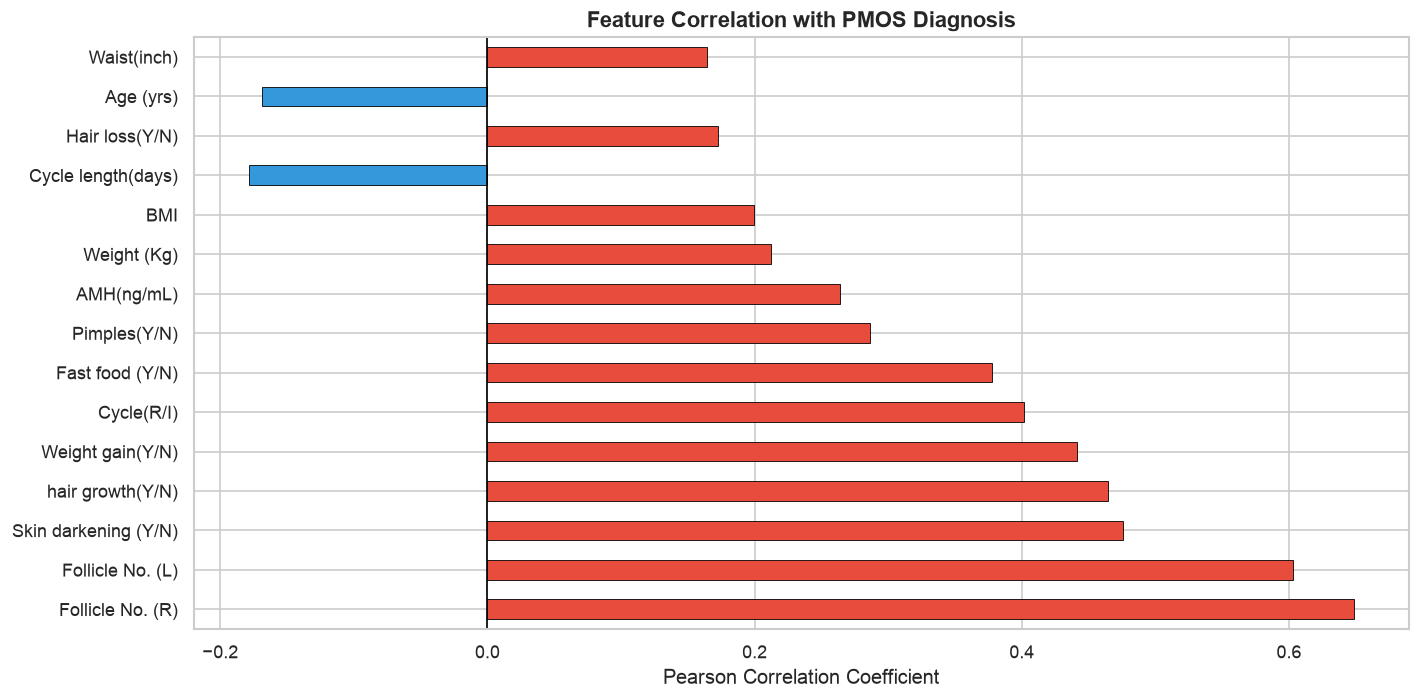

In [20]:
# Top features correlated with PMOS target
print('=== TOP FEATURES CORRELATED WITH PMOS ===')
target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print('\nTop 15 most correlated features:')
print(target_corr.head(15).to_string())

# Bar chart
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr.head(15)]
target_corr.head(15).plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Feature Correlation with PMOS Diagnosis', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('outputs/plots/07_target_correlation.png', bbox_inches='tight')
plt.show()

---
### Cell 13 — Outlier Detection

In [21]:
# IQR-based outlier detection — continuous columns only
print('=== OUTLIER DETECTION (IQR Method) ===')
print('Note: Binary columns excluded — IQR not valid for 0/1 data\n')

outlier_summary = []

for col in numerical_df.columns:
    if col == target_col:
        continue
    
    # Skip binary columns (only contain 0 and 1)
    unique_vals = df[col].dropna().unique()
    if set(unique_vals).issubset({0, 1}):
        continue
    
    # Skip low cardinality columns (fewer than 5 unique values)
    if len(unique_vals) < 5:
        continue
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (n_outliers / len(df)) * 100
    
    outlier_summary.append({
        'Feature'    : col,
        'Outliers'   : n_outliers,
        'Outlier %'  : round(pct, 2),
        'Lower Bound': round(lower, 3),
        'Upper Bound': round(upper, 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print('Top 15 continuous features with most outliers:')
print(outlier_df.head(15).to_string(index=False))

=== OUTLIER DETECTION (IQR Method) ===
Note: Binary columns excluded — IQR not valid for 0/1 data

Top 15 continuous features with most outliers:
               Feature  Outliers  Outlier %  Lower Bound  Upper Bound
     No. of aborptions       104     19.220        0.000        0.000
      Pulse rate(bpm)         94     17.380       69.000       77.000
    Cycle length(days)        77     14.230        2.500        6.500
            AMH(ng/mL)        52      9.610       -5.363       14.298
                FSH/LH        48      8.870       -2.398        7.774
  I   beta-HCG(mIU/mL)        46      8.500     -440.840      740.040
            PRG(ng/mL)        39      7.210       -0.050        0.750
        Vit D3 (ng/mL)        31      5.730        0.250       55.050
            RBS(mg/dl)        30      5.550       69.500      129.500
          LH_FSH_Ratio        29      5.360       -0.428        1.386
           TSH (mIU/L)        27      4.990       -1.655        6.705
            LH

---
### Cell 14 — Symptom Analysis
Binary symptoms: hair loss, acne, weight gain, cycle irregularity

=== BINARY SYMPTOM COLUMNS ===
  → Pregnant(Y/N)
  → Weight gain(Y/N)
  → hair growth(Y/N)
  → Skin darkening (Y/N)
  → Hair loss(Y/N)
  → Pimples(Y/N)
  → Fast food (Y/N)
  → Reg.Exercise(Y/N)

=== SYMPTOM PREVALENCE BY PMOS STATUS ===
             Symptom  PMOS Positive %  PMOS Negative %  Difference
Skin darkening (Y/N)           62.100           15.400      46.800
    Weight gain(Y/N)           68.400           22.800      45.600
    hair growth(Y/N)           57.100           12.900      44.200
     Fast food (Y/N)           78.500           38.300      40.200
        Pimples(Y/N)           69.500           39.000      30.500
      Hair loss(Y/N)           57.600           39.300      18.300
   Reg.Exercise(Y/N)           28.800           22.800       6.000
       Pregnant(Y/N)           36.200           39.000      -2.900


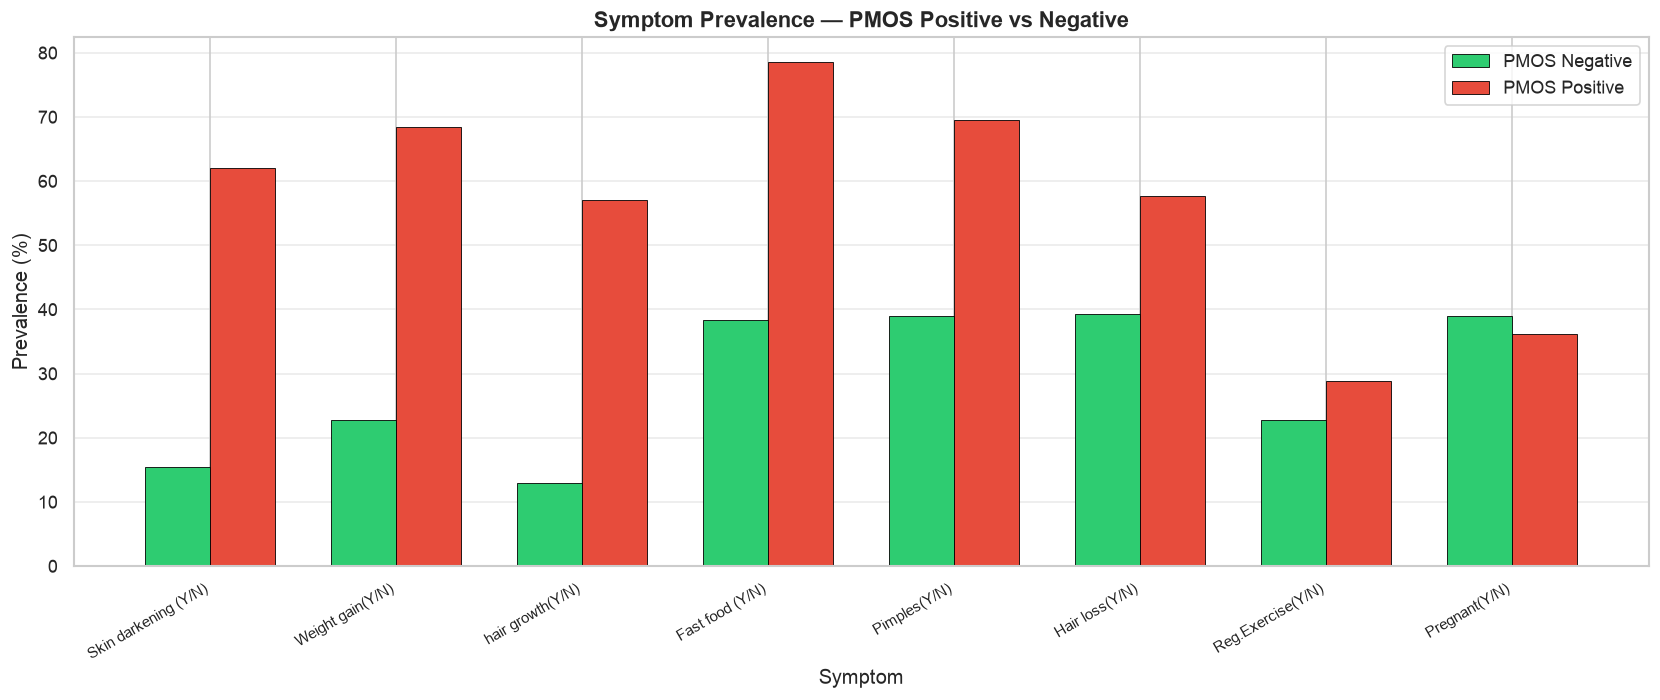

In [22]:
# Identify symptom columns (binary 0/1 features)
binary_cols = [
    col for col in df.columns
    if df[col].dropna().isin([0, 1]).all() and col != target_col
]

print('=== BINARY SYMPTOM COLUMNS ===')
for col in binary_cols:
    print(f'  → {col}')

if len(binary_cols) > 0:
    # Symptom prevalence in PMOS+ vs PMOS-
    symptom_data = []
    for col in binary_cols:
        pmos_pos = df[df[target_col] == 1][col].mean() * 100
        pmos_neg = df[df[target_col] == 0][col].mean() * 100
        symptom_data.append({
            'Symptom': col,
            'PMOS Positive %': round(pmos_pos, 1),
            'PMOS Negative %': round(pmos_neg, 1),
            'Difference': round(pmos_pos - pmos_neg, 1)
        })
    
    symptom_df = pd.DataFrame(symptom_data).sort_values('Difference', ascending=False)
    print('\n=== SYMPTOM PREVALENCE BY PMOS STATUS ===')
    print(symptom_df.to_string(index=False))
    
    # Plot top symptoms
    top_symptoms = symptom_df.head(8)
    x = range(len(top_symptoms))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(14, 6))
    bars1 = ax.bar([i - width/2 for i in x], top_symptoms['PMOS Negative %'],
                   width, label='PMOS Negative', color='#2ecc71', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar([i + width/2 for i in x], top_symptoms['PMOS Positive %'],
                   width, label='PMOS Positive', color='#e74c3c', edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Symptom')
    ax.set_ylabel('Prevalence (%)')
    ax.set_title('Symptom Prevalence — PMOS Positive vs Negative', 
                 fontsize=13, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(top_symptoms['Symptom'], rotation=30, ha='right', fontsize=9)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    
    plt.tight_layout()
    plt.savefig('outputs/plots/08_symptom_analysis.png', bbox_inches='tight')
    plt.show()

---
### Cell 15 — Save Cleaned Data & EDA Summary

In [23]:
# Save cleaned dataframe for Block 2
df.to_csv('../artifacts/pmos_eda_clean.csv', index=False)
print('✅ Cleaned data saved to ../artifacts/pmos_eda_clean.csv')

# Final EDA Summary
print('\n' + '='*55)
print('         BLOCK 1 — EDA SUMMARY COMPLETE')
print('='*55)
print(f'  Total patients          : {len(df)}')
print(f'  Total features          : {df.shape[1]}')
print(f'  PMOS Positive patients  : {(df[target_col]==1).sum()}')
print(f'  PMOS Negative patients  : {(df[target_col]==0).sum()}')
print(f'  Class imbalance ratio   : {(df[target_col]==0).sum()/(df[target_col]==1).sum():.2f}:1')
print(f'  Missing values          : {df.isnull().sum().sum()}')
print(f'  Duplicate rows          : 0 (removed)')
print(f'  LH/FSH ratio created    : Yes')
print(f'  Plots saved to          : outputs/plots/')
print('='*55)
print('\n➡️   Next: Block 2 — Feature Selection & Preprocessing')

✅ Cleaned data saved to data/processed/pmos_eda_clean.csv

         BLOCK 1 — EDA SUMMARY COMPLETE
  Total patients          : 541
  Total features          : 46
  PMOS Positive patients  : 177
  PMOS Negative patients  : 364
  Class imbalance ratio   : 2.06:1
  Missing values          : 542
  Duplicate rows          : 0 (removed)
  LH/FSH ratio created    : Yes
  Plots saved to          : outputs/plots/

➡️   Next: Block 2 — Feature Selection & Preprocessing


---
## ✅ Block 1 Complete!

### What we did:
- ✅ Loaded and inspected the PMOS dataset
- ✅ Checked for duplicates and missing values
- ✅ Analysed target variable distribution and class imbalance
- ✅ Explored hormone distributions (LH, FSH, AMH etc.)
- ✅ Computed LH/FSH ratio — key clinical marker
- ✅ Analysed metabolic features by PMOS status
- ✅ Built correlation heatmap
- ✅ Detected outliers using IQR method
- ✅ Analysed symptom prevalence
- ✅ Saved cleaned data for Block 2


## 📊 Block 1 — EDA Complete Insights

---

### 1. Dataset Overview
- **541 patients × 45 features**
- Target: `PCOS (Y/N)` — binary classification (0 = Negative, 1 = Positive)
- 2 identifier columns (`Sl. No`, `Patient File No.`) — will be dropped in Block 2
- `Unnamed: 44` — 99.6% missing, completely empty column — will be dropped

---

### 2. Data Quality Issues Found
| Issue | Column | Action in Block 2 |
|---|---|---|
| 99.6% missing | Unnamed: 44 | Drop column |
| Wrong dtype (object) | AMH(ng/mL) | Converted to float ✅ |
| Wrong dtype (object) | II beta-HCG(mIU/mL) | Convert to float |
| 1 missing value | Fast food (Y/N) | Impute with mode |
| 1 missing value | Marraige Status (Yrs) | Impute with median |
| Extreme outliers | FSH, LH, FSH/LH | Data entry errors suspected |

---

### 3. Class Imbalance
- **PMOS Negative: 364 (67.3%) vs PMOS Positive: 177 (32.7%)**
- Imbalance ratio: **2.06:1** — moderate imbalance
- Not severe enough to panic but needs handling
- **Action:** SMOTE + ADASYN in Block 2
- **Evaluation metric:** PR-AUC preferred over ROC-AUC for imbalanced data

---

### 4. Hormone Analysis (Image 1)

**FSH(mIU/mL):**
- Both groups concentrated near 0-50 range
- Extreme outlier visible at 5052 mIU/mL — likely data entry error
- Not a strong visual separator between groups

**LH(mIU/mL):**
- PMOS+ group shows extreme outlier at 2018 mIU/mL
- Most values clustered near 0-25 range
- Extreme values are clinically suspicious — investigate

**FSH/LH ratio:**
- Similar distribution shape for both groups
- Extreme outlier at 1372 — data quality concern
- The ratio itself is more informative than raw values

**TSH(mIU/L):**
- PMOS- patients show wider TSH spread
- Extreme value at 65 mIU/L (normal range 0.4-4.0)
- Suggests thyroid comorbidity in some patients

**AMH(ng/mL) ← Most important hormone:**
- PMOS+ patients clearly shifted RIGHT (higher AMH)
- Higher AMH = more antral follicles = stronger PMOS signal
- Best visually separating hormone between the two groups
- **Strong predictor — will rank high in feature importance**

**PRL(ng/mL):**
- Distributions heavily overlapping between groups
- Weak discriminating power for PMOS diagnosis
- May be dropped after feature selection in Block 2

---

### 5. LH/FSH Ratio Analysis (Image 2)

**Critical Finding:**
- PMOS- mean ratio: **0.510** (normal range)
- PMOS+ mean ratio: **3.271** (elevated — classic PMOS signal)
- PMOS+ has extreme outlier at **466** — almost certainly data entry error
- The boxplot is completely squashed due to this outlier
- **Clinical threshold of 2.0** — most PMOS+ patients cluster below 2
  which suggests LH/FSH ratio alone is not sufficient for diagnosis
  (consistent with literature — Rotterdam criteria uses multiple markers)

**Note:** The extreme outlier (466) needs investigation in Block 2.
A ratio of 466 is physiologically impossible — will be capped.

---

### 6. Metabolic Features Analysis (Image 3)

**Weight (Kg) + BMI:**
- PMOS+ patients show slightly higher weight and BMI
- Overlap is large — not a strong standalone predictor
- Combined with other features will be useful

**Blood Group:**
- Identical distribution between groups
- **Drop this feature** — no clinical relevance to PMOS

**Pulse Rate:**
- Almost identical between groups
- **Weak predictor** — may be dropped after feature selection

**Hip + Waist (inch):**
- PMOS+ patients show larger measurements
- Consistent with metabolic weight gain pattern
- Waist:Hip ratio more informative than raw measurements

**Waist:Hip Ratio:**
- PMOS- slightly higher median than PMOS+
- Unexpected — fat distribution differs from weight gain pattern
- Interesting finding worth noting

**Weight gain (Y/N):**
- Most dramatic visual difference in metabolic panel
- PMOS+ shows much higher prevalence — consistent with symptom analysis
- **Strong predictor**

**BP Systolic + Diastolic:**
- Nearly identical distributions between groups
- One extreme outlier (BP = 12 mmHg) — data entry error
- **Weak cardiovascular signal at this stage**

---

### 7. Correlation with Target (Top Features)
| Rank | Feature | Correlation |
|---|---|---|
| 1 | Follicle No. (R) | **0.648** ← strongest |
| 2 | Follicle No. (L) | **0.603** |
| 3 | Skin darkening | 0.476 |
| 4 | Hair growth | 0.465 |
| 5 | Weight gain | 0.441 |
| 6 | Cycle (R/I) | 0.402 |
| 7 | Fast food | 0.378 |
| 8 | AMH | 0.264 |

**Key insight:** Follicle count (left + right ovary) is the 
single strongest predictor — consistent with clinical PMOS 
diagnosis which requires polycystic ovarian morphology.

---

### 8. Outlier Analysis
| Feature | Outlier % | Clinical Interpretation | Action |
|---|---|---|---|
| No. of abortions | 19.2% | Low-count variable, IQR unsuitable | Keep |
| Pulse rate | 17.4% | One extreme low value (13 bpm) — data error | Cap in Block 2 |
| Cycle length | 14.2% | PMOS causes irregular cycles — real signal | Keep |
| AMH | 9.6% | High AMH = severe PMOS — real signal | Keep |
| I beta-HCG | 8.5% | Max 32,460 — extreme, likely pregnancy cases | Investigate |
| FSH/LH | 8.9% | Extreme ratio 1372 — data entry error | Cap in Block 2 |

---

### 9. Symptom Analysis — Critical Findings
| Symptom | PMOS+ | PMOS- | Difference | Clinical Meaning |
|---|---|---|---|---|
| Skin darkening | 62.1% | 15.4% | **+46.8%** | Acanthosis nigricans — insulin resistance |
| Weight gain | 68.4% | 22.8% | **+45.6%** | Metabolic dysfunction |
| Hair growth | 57.1% | 12.9% | **+44.2%** | Hirsutism — hyperandrogenism |
| Fast food | 78.5% | 38.3% | **+40.2%** | Lifestyle/dietary factor |
| Pimples | 69.5% | 39.0% | **+30.5%** | Androgen excess — acne |
| Hair loss | 57.6% | 39.3% | **+18.3%** | Androgenic alopecia |
| Exercise | 28.8% | 22.8% | +6.0% | Weak signal |
| **Pregnant** | **36.2%** | **39.0%** | **-2.9%** | **Not discriminating** |

### ⚠️ Critical Clinical Observation
> **Pregnant(Y/N) shows -2.9% difference** — PMOS positive and 
> negative patients have virtually identical pregnancy rates.
> This statistically confirms that pregnancy outcome does NOT 
> capture PMOS reproductive impact.
> 
> **Decision:** Reproductive risk will be modelled using 
> hormonal markers — LH/FSH ratio, AMH, antral follicle count, 
> and cycle regularity — which honestly reflect ovulatory 
> function rather than its binary outcome.

---



---

### ➡️ Next: Block 2 — Preprocessing & Feature Selection
**Actions planned:**
- Drop irrelevant columns
- Fix remaining dtype issues (II beta-HCG)
- Impute 2 missing values
- Cap extreme outliers (FSH, LH, pulse rate)
- Chi-square + ANOVA + LASSO feature selection
- SMOTE + ADASYN for class imbalance